# Computer Vision, Assignment 4: Model Fitting and Local Optimization

In this assignment, you will learn how to robustly estimate camera parameters and how to jointly optimize the scene geometry. 
You will mainly use RANSAC and Bundle Adjustment.

Please see Canvas for detailed instructions on what is expected for a passing/higher grade.
All computer exercises that are not marked **OPTIONAL** are "mandatory" in the sense described on Canvas.


### Submission Requirements:
Your final lab submission should include:
1. Your edited **notebook file** (`.ipynb`).
2. An **HTML printout** of the executed notebook with all outputs visible: File → Save and export Notebook As → HTML
3. A **pdf report** containing answers to the theoretical exercises (see separate document).


### Reusing functions from prior assignment:
In this assignment, you will build on your prior work. Many of the exercises require you to use functions implemented in assignment 3. To do so most easily, we recommend that you paste those functions into `helpers.py` and import them here by e.g. `from helpers import estimate_F_DLT`. 

In [1]:
# for creating responsive plots
%matplotlib widget  

import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

# Note: These functions are provided for your convenience, use them where needed
from supplied import pflat, plot_camera, rital

# Estimate Essential Matrix using RANSAC

#### *Theoretical exercises 1-2* (see pdf)

## Computer Exercise 1
<figure align="center">
    <img alt="left" src="data/round_church1.jpg" width="250px">
&nbsp; &nbsp; &nbsp; &nbsp;
    <img alt="right" src="data/round_church2.jpg" width="250px">
    <img alt="right" src="data/round_church_recon.png" width="250px">
    <figcaption>Figure 1: Two images of a church and an example of the obtained 3D reconstruction.</figcaption>
</figure>

The goal of this exercise is to robustly estimate essential matrix $E$ from point matches between the two images. For this, we will use RANSAC with an eight point solver.

The data provided contains calibration matrix $K$, which is the same for both images, and a cell $\mathbf{x}$ with matched image points for the two images. Note that $\mathbf{x}$ are noisy and contain some fraction of outliers.

In [2]:
# First we supply some preliminaries, just loading images and data
img1 = plt.imread('./data/round_church1.jpg')
img2 = plt.imread('./data/round_church2.jpg')

data = sp.io.loadmat('./data/compEx1data.mat')
K = data["K"]
x = [x.astype(np.float32) for x in data['x'][0]]

### Task 1.1

First, compute the essential matrix $E$ with an eight point algorithm using all the point correspondences. Remember to normalize image points using $K$ beforehand. Then convert it to a fundamental matrix $F$. Recall that in Assignment 3, you created functions `estimate_F_DLT(x1s, x2s)`, `enforce_essential(E_approx)`, and `convert_E_to_F(E,K1,K2)`.

In [3]:
# Optional imports
from helpers import estimate_F_DLT, enforce_essential, convert_E_to_F, enforce_fundamental

In [4]:
x1s = x[0] # points from image 1, homogeneous
x2s = x[1] # corresponding points from image 2, homogeneous
inv_K = np.linalg.inv(K)
x1s_K_norm = inv_K @ x1s
x2s_K_norm = inv_K @ x2s

# Insert code where you compute the essential matrix
E_tilde = estimate_F_DLT(x1s_K_norm, x2s_K_norm) # needs image plane points, normalized ok
E_tilde = enforce_essential(E_tilde)

F_approx = convert_E_to_F(E_tilde, K, K)
enforce_fundamental(F_approx)

AssertionError: Determinant of Fundamental matrix is not zero!


### Task 1.2 

Compute the epipolar lines $\mathbf{l}_2 = F\mathbf{x}_1$ and $\mathbf{l}_1 = F^T\mathbf{x}_2$. Compute the RMS distance between the image points ($\mathbf{x}_1$ and $\mathbf{x}_2$) and corresponding epipolar lines ($\mathbf{l}_1$ and $\mathbf{l}_2$, respectively). 

\begin{align}
& e_{RMS} = \sqrt{\frac{1}{2m}
\left(
\sum_{i=1}^{m} d^2({\mathbf{x}_1}_i,{\mathbf{l}_1}_i) + 
\sum_{i=1}^{m} d^2({\mathbf{x}_2}_i,{\mathbf{l}_2}_i)
\right)
},\nonumber \\
& \text{where }~d(\mathbf{x}, \mathbf{l}) = \frac{|l_{1}x_{1}+l_{2}x_{2}+l_{3}|}{\sqrt{l_{1}^2+l_{2}^2}}.
\end{align}

In Assignment 3, you implemented the distances $d(\mathbf{x}, \mathbf{l})$ from image points to the corresponding epipolar lines for the second image in the function `compute_epipolar_errors(F, x1s, x2s)`.


**HINT:** If you transpose the fundamental matrix and change the order of the correpondences, i.e. run `compute_epipolar_errors(F.T, x2s, x1s)` you can obtain the errors to the epipolar lines in the first image.

In [5]:
# Optional imports
from helpers import compute_epipolar_errors 

In [6]:
# ------ Your code here ------
nr_of_points = x1s.shape[1]

# Compute the epipolar lines, l1 and l2
d1 = compute_epipolar_errors(F_approx, x1s, x2s)**2
d2 = compute_epipolar_errors(F_approx.T, x2s, x1s)**2
factor = 1/(2*nr_of_points)
# Compute the RMS distance
e_RMS = np.sqrt(factor*(np.sum(d1) + np.sum(d2)))
print('e_RMS =',e_RMS)

e_RMS = 156.03930862037853


### Task 1.3

Plot two separate histograms with 100 bins for the epipolar errors $\{d({\mathbf{x}_1}_i,{\mathbf{l}_1}_i)\}$ in the first image and $\{d({\mathbf{x}_2}_i,{\mathbf{l}_2}_i)\}$ in the second image, respectively. See for example your solution to Assignment 3 Computer Exercise 2.2 for some code on plotting histograms.

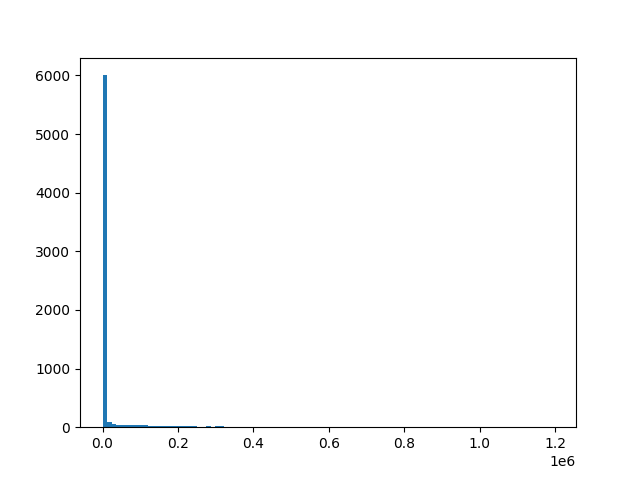

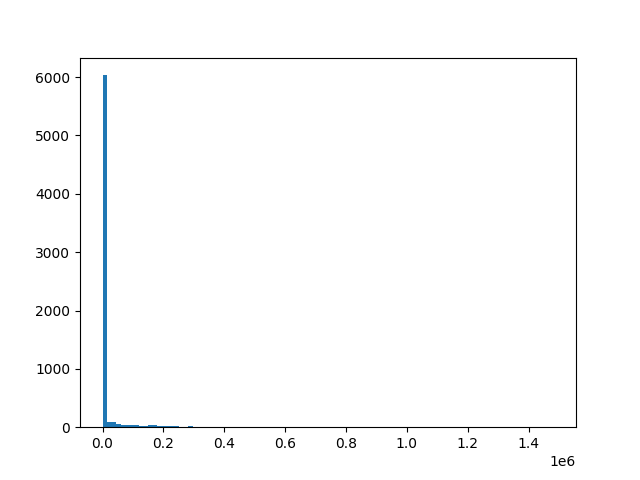

In [7]:
# ------ Your code here ------
fig1 = plt.figure()
ax1 = fig1.add_subplot()
ax1.hist(d1, bins=100)
fig1.set_label('error 1')
plt.show()

fig2 = plt.figure()
ax2 = fig2.add_subplot()
ax2.hist(d2, bins=100)
fig2.set_label('error 2')
plt.show()

### Task 1.4

Pick 20 points in the first image at random and plot these in the same figure as the image. Also plot the corresponding epipolar lines in the same image using the function `rital`. Repeat the plot for the second image.

Q: **Do the plots look reasonable, are points close to the epipolar lines? If not, what do you think could be the cause of the bad estimate?** 

A: The points are not close enough to the estimated lines. This could be because of outliers making the eight point algorithms for finding E not accurate enough since the algorithm uses all points in the estimation.   

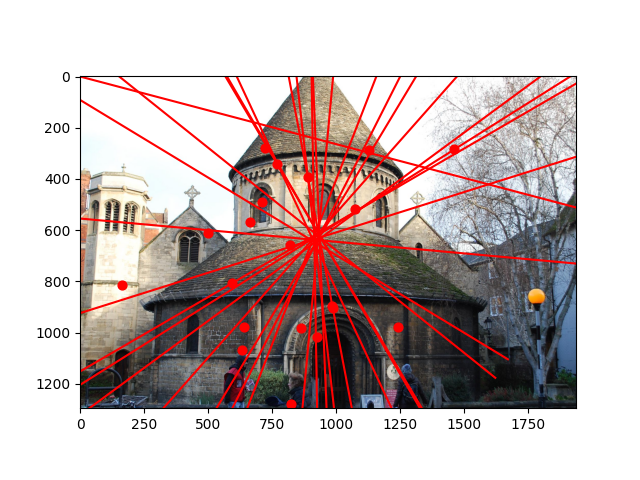

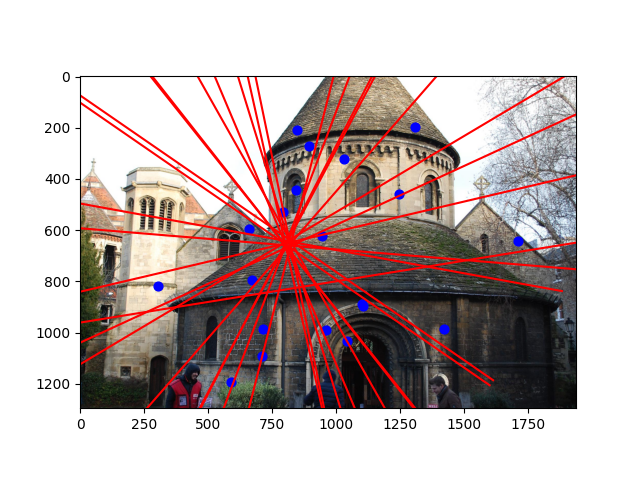

In [8]:
# ------ Your code here ------
import random
ind = [x for x in range(x1s.shape[1])]
random_points = random.choices(ind, k=20)

fig3 = plt.figure()
ax3 = fig3.add_subplot()

ax3.imshow(img1)
for i in random_points:
    ax3.scatter(x1s[0,i], x1s[1,i], color='red', s=40)
    l2 = np.matmul(F_approx, x1s[:,i])
    l2 = np.array([l2/l2[-1]])
    rital(l2)
plt.show()

#---- image 2-----#
fig4 = plt.figure()
ax4 = fig4.add_subplot()

ax4.imshow(img2)
for i in random_points:
    ax4.scatter(x2s[0,i], x2s[1,i], color='blue', s=40)
    l1 = F_approx.T @ x2s[:,i]
    l1 = np.array([l1/l1[-1]])
    rital(l1)
plt.show()

### Task 1.5

Next, use RANSAC to robustly compute $E$. Create a function `estimate_E_robust(x1, x2, eps)` that does it, where `eps` is the inlier threshold. Remember again to normalize `x1` and `x2` using $K$ beforehand. Note that for this problem of estimating $E$, a point correspondence $({\mathbf{x}_1}_i, {\mathbf{x}_2}_i)$ is a single measurement. Use the same eight point solver as above.

Note that this time only a subset of correspondences will be used by this solver (since in the RANSAC loop, you first randomly sample a subset of correspondences and then compute candidate $E$ from this subset).

Finally, to make RANSAC work, you need to implement an error function that measures how far a single measurement ($({\mathbf{x}_1}_i, {\mathbf{x}_2}_i)$) is to the candidate model ($E$). Use the following error function: $\frac12 \left ( d^2({\mathbf{x}_1}_i,{\mathbf{l}_1}_i) + d^2({\mathbf{x}_2}_i,{\mathbf{l}_2}_i)\right )$, where the epipolar lines ${\mathbf{l}_j}_i$ are computed as before but using $E$ (and therefore are normalized). This error should be familiar to you based on the previous exercises, reuse your implementation from there!

A suggested inlier threshold is 2px (which should also be normalized, see function description below). 

Q: **How many inliers did you get for the returned solution of $E$?**

A: Number of inliers was 5808

In [9]:
def estimate_E_robust(x1, x2, eps, seed=None):
    """
    RANSAC estimate of essential matrix using normalized correspondences x1 and x2 and a normalized threshold.
    Note: Make sure to normalize things before using it in this function!
    -------------------------------------------
    x1: Normalized keypoints in image 1 - 3xN np.array or 2xN np.array, as you desire 
    x2: Normalized keypoints in image 2 - 3xN np.array or 2xN np.array, as you desire 
    eps: Normalized inlier threshold - float

    Returns:
    E: 3x3 essential matrix
    inliers: The inlier points
    errs: The epipolar errors
    iters: How many iterations it took
    """
    done = False
    iters = 0
    best_inliers = 0
    counter = 0
    inliers_x1 = []
    inliers_x2 = []
    inlier_goal = 0.75*x1.shape[1]
    while not done:
        counter += 1
        count_inliers = 0
        random_sample = random.sample(range(len(x1[1])), 8)
        r_samples_x1 = np.vstack([x1[:,i] for i in random_sample]).T
        r_samples_x2 = np.vstack([x2[:,i] for i in random_sample]).T

        E_tild = enforce_essential(estimate_F_DLT(r_samples_x1, r_samples_x2)) # Giving 8 samples to DLT

        e1 = compute_epipolar_errors(E_tild, x1, x2)**2 
        e2 = compute_epipolar_errors(E_tild.T, x2, x1)**2

        for idx, (error1, error2) in enumerate(zip(e1, e2)):
            distance_x1_x2 = (1/2)*(error1+error2) 
            if distance_x1_x2 < eps**2:
                count_inliers += 1
                inliers_x1.append(x1[:,idx])
                inliers_x2.append(x2[:,idx])
        if count_inliers > best_inliers:
            best_E = E_tild
            best_inliers = count_inliers
        elif count_inliers <= best_inliers:
            inliers_x1 = [] # reset inlier list
            inliers_x2 = []
        if best_inliers >= inlier_goal:
            done = True
            errs = (e1,e2)
            inliers = (inliers_x1, inliers_x2)
            E = best_E

        #print(f'inliers at iteration {counter} is = {count_inliers}')
        #print(f'best inliers at iteration {counter} is = {best_inliers}')
        #print('inlier goal', inlier_goal)
        iters += 1

    return E, inliers, errs, iters

### Task 1.6

Again, compute the RMS distance between the image points and corresponding estimated epipolar lines in both images. Also plot a histogram of epipolar errors for both images as before. 

Q: **Which is the better estimate of the essential matrix, and why?** Repeat plotting 20 random points with the corresponding epipolar lines, but this time pick random points from the subset of correspondences that are ***inliers***.

A: The robust is a better estimation of the Essential matrix since it reduces the negative effects of outliers. 

Iterations: 29
nr of inliers 5801
e_RMS = 0.09411951405793405


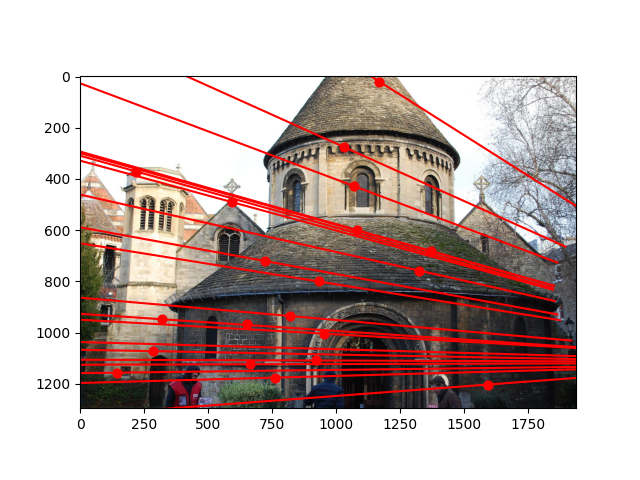

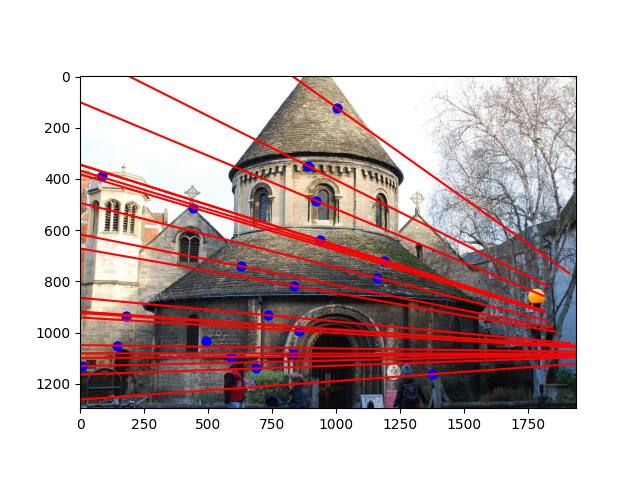

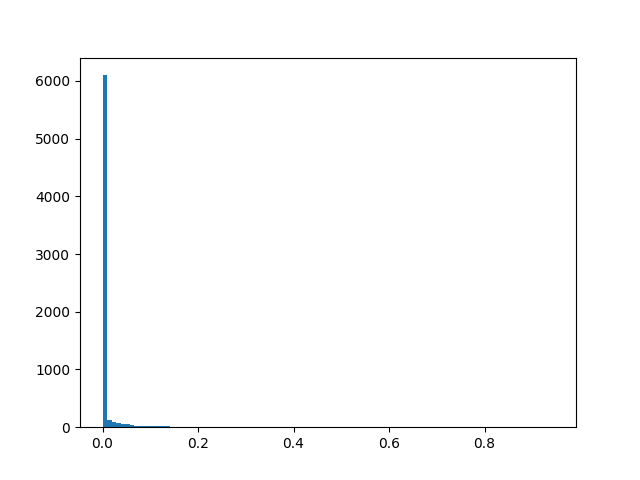

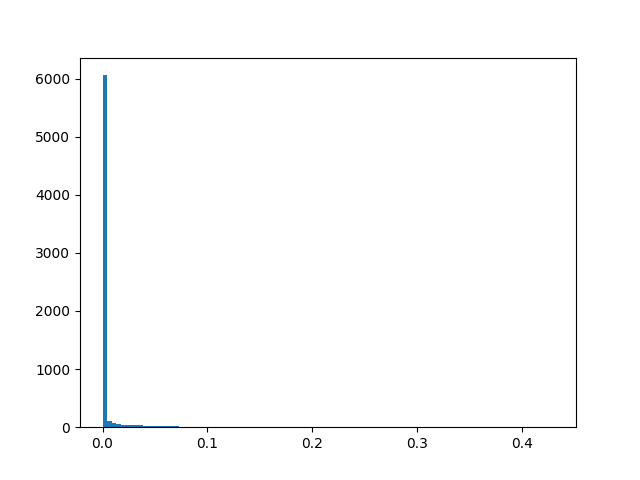

In [10]:
# ------ Your code here ------
threshold_px = 3
eps_K_norm = threshold_px / K[0,0]

E, inliers, errs, iters = estimate_E_robust(x1s_K_norm, x2s_K_norm, eps_K_norm, seed=None)
e1, e2 = errs
print('Iterations:', iters)
inliers_x, inliers_y = inliers
inliers_x = np.vstack([inliers_x ]).T
inliers_y = np.vstack([inliers_y ]).T
nr_of_inliers = len(inliers_x[0])
print('nr of inliers', nr_of_inliers)

random_sample_RANSAC = random.sample(range(nr_of_inliers), 20)
r_x1s = np.vstack([inliers_x[:,i] for i in random_sample_RANSAC]).T
r_x2s = np.vstack([inliers_y[:,i] for i in random_sample_RANSAC]).T

# Compute RMS distance
factor = 1/(2*nr_of_inliers) 
e_RMS = np.sqrt(factor*(np.sum(e1) + np.sum(e2)))
print(f'e_RMS = {e_RMS}')

# Plotting image 

fig51 = plt.figure()
ax51 = fig51.add_subplot()

ax51.imshow(img2)
inv_K = np.linalg.inv(K)
for i in random_sample_RANSAC:
    ax51.scatter(x2s[0,i], x2s[1,i], color='red', s=40)
    l2 = inv_K.T @ E @ x1s_K_norm[:,i]
    l2 = np.array([l2/l2[-1]])
    rital(l2)
plt.show()

fig52 = plt.figure()
ax52 = fig52.add_subplot()

ax52.imshow(img1)
for j in random_sample_RANSAC:
    ax52.scatter(x1s[0,j], x1s[1,j], color='blue', s=40)
    l1 = inv_K.T @ E.T @ x2s_K_norm[:,j]
    l1 = np.array([l1/l1[-1]])
    rital(l1)
plt.show()

# Plotting hitogram 
fig6 = plt.figure()
ax6 = fig6.add_subplot()
ax6.hist(e1, bins=100)
fig6.set_label('error 1')
plt.show()

fig7 = plt.figure()
ax7 = fig7.add_subplot()
ax7.hist(e2, bins=100)
fig7.set_label('error 2')
plt.show()

## Computer Exercise 2
<figure align="center">
    <img alt="left" src="data/fountain1.png" width="250px">
&nbsp; &nbsp; &nbsp; &nbsp;
    <img alt="right" src="data/fountain2.png" width="250px">
    <img alt="right" src="data/fountain_recon.png" width="250px">
    <figcaption>Figure 2: Two images of a fountain and an example of the obtained 3D reconstruction.</figcaption>
</figure>

In this exercise you will build a 2-view reconstruction pipeline that connects feature extraction,
matching, robust essential matrix estimation from the previous computer exercise, and triangulation.

You can use the two supplied images from the data and the intrinsics provided. We load the required data for your convenience below:

In [11]:
data = sp.io.loadmat('./data/compEx2data.mat')
K = data['K']
img1 = (plt.imread('./data/fountain1.png') * 255).astype('uint8')
img2 = (plt.imread('./data/fountain2.png') * 255).astype('uint8')

### Task 2.1

We will begin by computing SIFT features and matching them. Since OpenCV has quite a difficult API for this we have supplied some code snippets. And you already learned much of the basics of this from Assignment 2, so we provide some basic code to get you started.

The implementation is based on their official guide for image matching (https://docs.opencv.org/3.4/dc/dc3/tutorial_py_matcher.html) and uses Lowe's ratio test to filter out matches that are too similar, this should be similar to what you have done in previous assignments.

In [12]:
# Some supplied code on how to compute matches using OpenCV

from cv2 import SIFT_create, cvtColor, COLOR_RGB2GRAY, FlannBasedMatcher, drawMatchesKnn
rgb2gray = lambda img: cvtColor(img, COLOR_RGB2GRAY)
sift = SIFT_create(contrastThreshold=0.02, edgeThreshold=10, nOctaveLayers=3)

# We detect keypoints and simultaneously describe them using SIFT
kp1, des1 = sift.detectAndCompute(rgb2gray(img1),None) # descriptor contains 128 bins with the number of gradients 
kp2, des2 = sift.detectAndCompute(rgb2gray(img2),None) 

# We use a k-NN-like system to find the most similar descriptions
all_matches = FlannBasedMatcher().knnMatch(des1, des2, k=2)

# Apply ratio test
# Here we filter out matches that are too similar to other matches (because then they are likely wrong)
# This is standard in OpenCV, see https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
matches = []
for m,n in all_matches:
    if m.distance < 0.75*n.distance:
        matches.append([m])



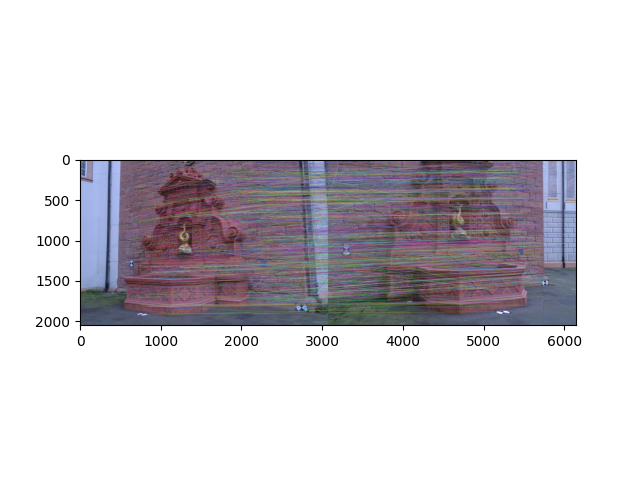

(<matplotlib.image.AxesImage at 0x17503773d10>, None)

In [13]:
# Run this code for a simple plot of the filtered matches

# Just making sure no other figures are impacting this one
plt.close()
plt.clf()   
plt.cla() 
# Here is some supplied code from https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
# Feel free to play around with it
img3 = drawMatchesKnn(img1,kp1,img2,kp2,matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img3,),plt.show()

Q: **Run the code above. Do the matches look reasonable?**

A: Its hard to tell but some matches that do not have a horizontal line in between them look like they would not be good matches. Others look like they might match. 

Q: **How many SIFT features did you find for the two images, respectively? How many total matches did you find? How many good matches did you find after the ratio test?**

A: 

19410 features for image 1

 17618 features for image 2. 

 Total matches: 19410

 Matches after ratio test with ratio 0.75: 1049

In [14]:
# ------ Your code here ------

# Count SIFT features per image
print(len(kp1))
print(len(des1))
print(len(kp2))
print(len(des2))
# Count number of total matches
print(len(all_matches))
# Count the number of good matches after the ratio-test
print(len(matches))

19410
19410
17618
17618
19410
1049


Now we supply a little more code just to make it easier. We extract the keypoints corresponding to the good matches and save them as x1 and x2. We do this because currently the type of kp1 etc... are OpenCV specific

In [29]:
# Supplied code for extracting numpy arrays from matching keypoints
# Note, x1 and x2 are in homogenous coordinates after this
x1 = np.array([[kp1[match[0].queryIdx].pt[0], kp1[match[0].queryIdx].pt[1]] for match in matches])
x2 = np.array([[kp2[match[0].trainIdx].pt[0], kp2[match[0].trainIdx].pt[1]] for match in matches])
x1 = np.vstack((x1.T, np.ones(x1.shape[0])))
x2 = np.vstack((x2.T, np.ones(x2.shape[0])))
x = np.array([x1, x2])

### Task 2.2

Now you should find the essential matrix describing the transformation between the two images.
Because not all matches are correct, you need to use RANSAC to find a set of good correspondences (inliers). 
To estimate the essential matrix use the function `estimate_E_robust(x1,x2,eps)` that you created in the previous computer exercise.

Q: **How many inliers did you find?**

A: 

nr of inliers after 1421 iterations: 805

In [30]:
# ------ Your code here ------
inv_K = np.linalg.inv(K)
x1, x2 = x 
x1_K_norm_task2 = inv_K @ x1
x2_K_norm_task2 = inv_K @ x2
# Compute the essential matrix based on the keypoint matches we just computed between the two images
E, inliers, errs, iters = estimate_E_robust(x1_K_norm_task2, x2_K_norm_task2, eps_K_norm)
inlier_x1, inlier_x2 = inliers
# Print the number of inliers
print(len(inlier_x1))

KeyboardInterrupt: 

### Task 2.3

After getting the robust essential matrix estimation, you should find the camera matrix of the second view. Remember that there are 4 possible solutions (see Theoretical Exercise 7 of HA3)! You should pick the solution that has more points in front of the camera. Remember, in Assigment 3 you implemented `extract_P_from_E(E)`

**Hint:** You need to perform triangulation by using a function from a previous computer exercise. The 3D points X and the 2d correspondences x1 and x2 wil also be needed for the next task in this assignment!

Q: **Which of the solutions seems correct to you?**

A: Solution P2a seems to have the most points in front of the camera

In [17]:
# Optional import
from helpers import extract_P_from_E, triangulate_3D_point_DLT

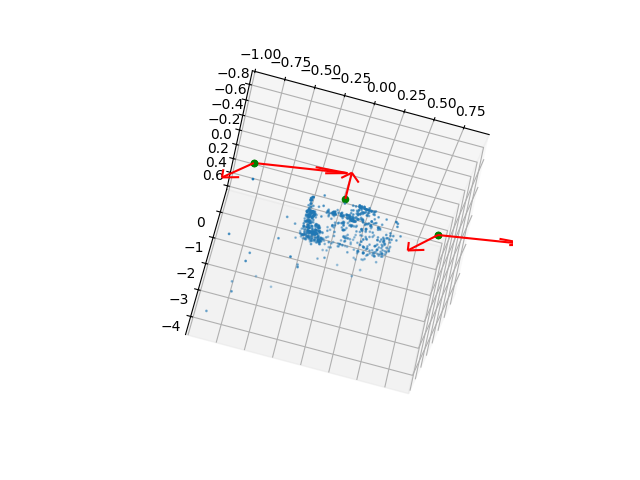

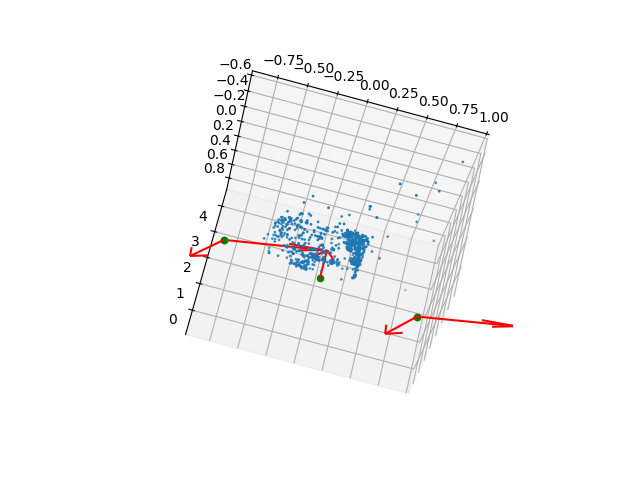

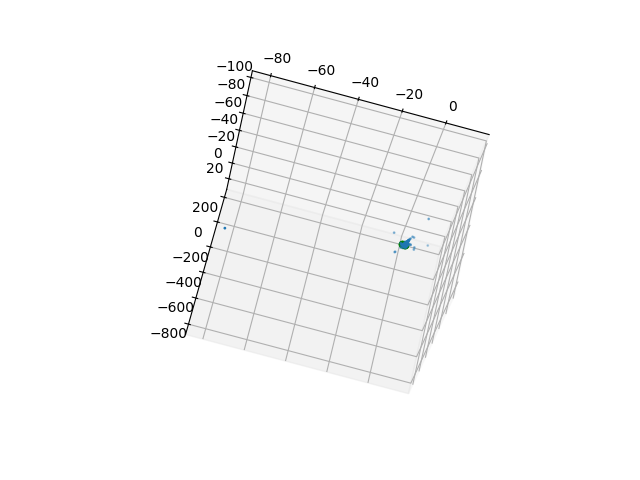

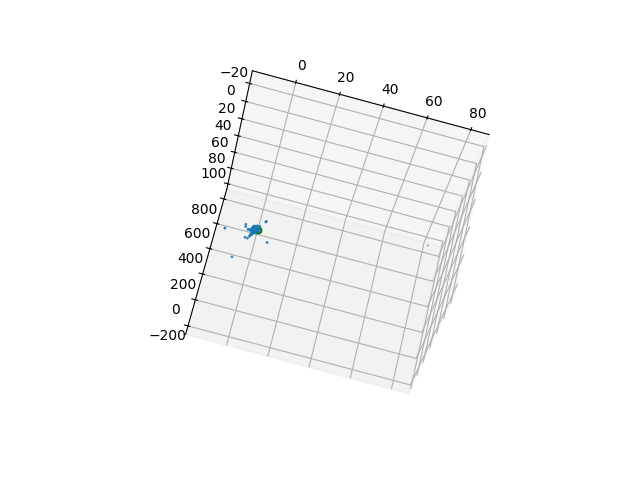

In [25]:
# ------ Your code here ------
#inlier_x1, inlier_x2 = inliers

stacked_inlier_x1 = np.vstack(inlier_x1).T
stacked_inlier_x2 = np.vstack(inlier_x2).T

nr_of_points = stacked_inlier_x1.shape[1]

X_tot_arr = []
# Compute the 4 possible camera matrices
P_arr = extract_P_from_E(E)
P1 = np.hstack((np.eye(3), np.zeros((3,1))))
for P2 in P_arr:
   X_arr = np.zeros((4, nr_of_points))
   for p in range(nr_of_points):
      X = triangulate_3D_point_DLT(x1_K_norm_task2[:,p], x2_K_norm_task2[:,p], P1, P2)
      X_arr[:,p] = X
   X_tot_arr.append(X_arr)

# Plot all (4) of them together with the triangulated 3D points X!
fig9 = plt.figure()
ax9 = fig9.add_subplot(projection="3d")
ax9.scatter(X_tot_arr[0][0], X_tot_arr[0][1], X_tot_arr[0][2], s=1)
plot_camera(P1, 1, ax=ax9)
plot_camera(P_arr[0], 1, ax=ax9)
plot_camera(P_arr[1], 1, ax=ax9)
plot_camera(P_arr[2], 1, ax=ax9)
plot_camera(P_arr[3], 1, ax=ax9)
ax9.view_init(elev=-29, azim=-92, roll=-14)
fig9.set_label("P2a")
plt.show()

fig10 = plt.figure()
ax10 = fig10.add_subplot(projection="3d")
ax10.scatter(X_tot_arr[1][0], X_tot_arr[1][1], X_tot_arr[1][2], s=1)
plot_camera(P1, 1, ax=ax10)
plot_camera(P_arr[0], 1, ax=ax10)
plot_camera(P_arr[1], 1, ax=ax10)
plot_camera(P_arr[2], 1, ax=ax10)
plot_camera(P_arr[3], 1, ax=ax10)
ax10.view_init(elev=-29, azim=-92, roll=-14)
fig10.set_label("P2b")
plt.show()

fig11 = plt.figure()
ax11 = fig11.add_subplot(projection="3d")
ax11.scatter(X_tot_arr[2][0], X_tot_arr[2][1], X_tot_arr[2][2], s=1)
plot_camera(P1, 1, ax=ax11)
plot_camera(P_arr[0], 1, ax=ax11)
plot_camera(P_arr[1], 1, ax=ax11)
plot_camera(P_arr[2], 1, ax=ax11)
plot_camera(P_arr[3], 1, ax=ax11)
ax11.view_init(elev=-29, azim=-92, roll=-14)
fig11.set_label("P2c")

plt.show()

fig12 = plt.figure()
ax12 = fig12.add_subplot(projection="3d")
ax12.scatter(X_tot_arr[3][0], X_tot_arr[3][1], X_tot_arr[3][2], s=1)
plot_camera(P1, 1, ax=ax12)
plot_camera(P_arr[0], 1, ax=ax12)
plot_camera(P_arr[1], 1, ax=ax12)
plot_camera(P_arr[2], 1, ax=ax12)
plot_camera(P_arr[3], 1, ax=ax12)
ax12.view_init(elev=-29, azim=-92, roll=-14)
fig12.set_label("P2d")
plt.show()

### Summary of reconstruction pipeline

In summary, you have performed a 2d-view reconstruction pipeline consisting of the following steps:
1. **Load the two images**, find SIFT features, and match them.

2. **Estimate the essential matrix** robustly using  
   `estimate_E_robust(x1, x2, eps)`.

3. **Compute the four possible camera matrix pairs** for the essential matrix, and for each pair:
   1. Triangulate the 3D points using the camera matrix pair and the matched image points.
   2. Compute the camera centers and principal directions of both cameras.
   3. Plot everything in 3D.

4. **Choose the correct solution** (out of the four) by selecting the one that yields the highest number of 3D points (inliers) lying in front of the cameras.  

The final visualization should resemble the right-most result in the first Figure of Computer Exercise 2 after removing most outliers.

This pipeline will come in handy for the project and somewhat resembles the first stage in any modern SfM pipeline like [COLMAP](https://github.com/colmap/colmap).

#### *Theoretical exercises 3* (see pdf)

## Computer Exercise 3

In this exercise you will use the solution from Computer Exercise 2 as a starting point and locally improve it using the Levenberg-Marquardt method. If you have doubts about the correctness of your solution from the earlier exercise, you can instead use the provided data in `compEx3data.mat` as starting solution (you can load it like `data = sp.io.loadmat('./data/compEx3data.mat')` and then use that for your x and camera matrices).

The goal is to refine the solution **3D points (not camera matrices, those you can assume fixed**).
You will loop over the 3D points and update them one by one using Levenberg-Marquardt (LM), please see the lecture notes or [Wikipedia page on Levenberg–Marquardt](https://en.wikipedia.org/wiki/Levenberg%E2%80%93Marquardt_algorithm) for more information.

In short, LM is an iterative method for minimizing a non-linear least squares objective
\begin{equation}
   F(v)=\|r(v)\|^2, 
\end{equation}
with respect to $v$.
In LM, the update is given by
\begin{equation}
\delta v =  - (J(v)^TJ(v)+\mu I)^{-1}J(v)^Tr(v),
\end{equation}
where $J(v)$ is the Jacobian of $r(v)$ at $v$.
Here $\mu>0$ is a damping factor that is adjusted adaptively and $v$ is the previous solution.
The new solution is $v+\delta v$ and we iterate until convergence (or for a fixed number of iterations).

We can also define the **reprojection error** to be: $\sum_{i=1}^m \left\|r_{i}(X_j) \right\|^2 $ (as in Equation (2) in the Theoretical Exercises)

In our setting, we have $v=X_j$ and $r(v)=r(X_j)$. Please see the main PDF for some more details about the definition of $r$ (e.g. Equation (3) for the definition).

You will have to implement three functions in this exercise:

1. `(err,res) = compute_reprojection_error(P_1,P_2,X_j,x_1j,x_2j)`: a function that computes the reprojection error ($\sum_{i=1}^m \left\|r_{i}(X_j) \right\|^2 $) given two cameras $P_i$, a 3D point $X_j$ and 2D points $x_{ij}$ in the images corresponding to the cameras $P_i$ and the 3D point $X_j$. It also returns the values of all the individual residuals as a second output, i.e., the residual vector $r(\mathbf{X}_j)$.
    
2. `(r,J) = linearize_reproj_err(P_1,P_2,X_j,x_1j,x_2j)`: a function that computes the linearization ($r$ and $J$) as described in Equation (7) in the Theoretical Exercises.
    
3. `delta_X_j = compute_update(r, J, mu)`: a function that computes the LM-update given $r$, $J$ and $\mu$ as described in Equation (9) in the Theoretical Exercises.

The idea is now to use *decoupled* LM, i.e. loop over the 3D points and refine them one by one.

Let's first start by implementing the functions in code!

**NOTE**: Below we have provided suggestion for the function signatures. However, you are free to implement the actual functions however you'd like. For example, you don't have to take the inputs and outputs on the exact form we suggest. This is one way to store the Jacobians, residuals, etc..., feel free to decide how you feel is best.

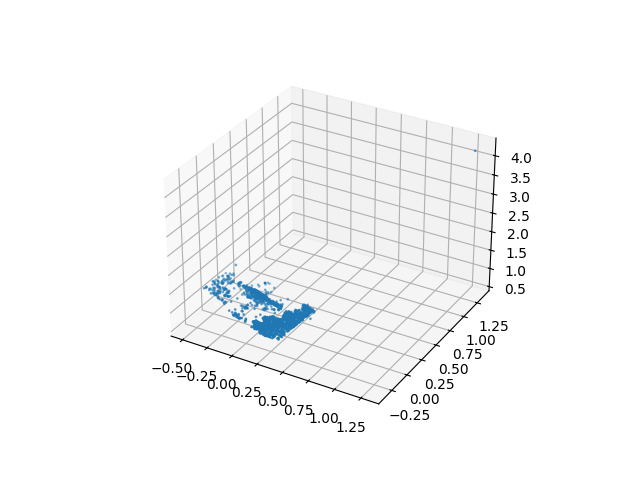

In [19]:
# Random useful commands:

# Computes the LM update .
# C = J.T @ J + mu * np.eye(J.shape[1])
# c = J.T @ r
# delta = -np.linalg.solve(C, c)

data = sp.io.loadmat('./data/compEx3data.mat')
XX = data['X']
x = data['x']
K = data['K']
P = data['P']
fig13 = plt.figure()
ax13 = fig13.add_subplot(projection="3d")
ax13.scatter(XX[0], XX[1], XX[2], s=1)
fig13.set_label("P2c")
plt.show()


In [20]:
def compute_reprojection_error(P_1, P_2, X_j, x_1j, x_2j):
    """
    Compute the reprojection error for a single 3D point.

    Parameters
    ----------
    P_1, P_2 : ndarray (3, 4)
        Projection matrices.

    X_j : ndarray (4,)
        3D homogeneous point.

    x_1j, x_2j : ndarray (2,)
        Observed image positions.

    Returns
    -------
    err : float 
        Reprojection error.

    r : Residual vector. For example, an ndarray of shape (2, 2)
        However, you can decide in your own implementation.
    """
    # computing projected points
    P1X = np.matmul(P_1, X_j) 
    P2X = np.matmul(P_2, X_j)
    projected_point_img1 = P1X/P1X[-1]
    projected_point_img2 = P2X/P2X[-1]
    
    r = np.zeros((1,4))
    r[0][0] = x_1j[0] - projected_point_img1[0]  # x coordinate error from camera 1
    r[0][1] = x_1j[1] - projected_point_img1[1]  # y coordinate error from camera 1
    r[0][2] = x_2j[0] - projected_point_img2[0]  # x coordinate error from camera 2
    r[0][3] = x_2j[1] - projected_point_img2[1]  # y coordinate error from camera 2

    err = np.sum(r**2)

    return err, r
    

In [21]:
def linearize_reproj_err(P_1, P_2, X_j, x_1j, x_2j):
    """
    Linearize the reprojection error for a single 3D point observed in two views.

    Parameters
    ----------
    P_1, P_2 : ndarray (3, 4)
        Camera matrices.

    X_j : ndarray (4,)
        Homogeneous 3D point.

    x_1j, x_2j : ndarray (2,)
        Observed image coordinates for this point in cameras 1 and 2.

    Returns
    -------
    r : Linearization of r. For example an ndarray of shape (4,) representing concatenated reprojection residuals: [r1_x, r1_y, r2_x, r2_y].
        However, you can decide for yourself how you want to store this.

    J : Linearization of J. For example, an ndarray of shape (4, 4) representing a concatenation of the two Jacobians
        However, you can decide for yourself how you want to store this.

    Notes
    -----
    This creates the linear system used in Levenberg-Marquardt.
    """
    J = np.zeros((4,4))
    P_arr = (P_1, P_2)
    for i, P in enumerate(P_arr):
        row1 = P[0, :]   
        row2 = P[1, :]
        row3 = P[2, :]

        a1 = row1 @ X_j   
        a2 = row2 @ X_j  
        b  = row3 @ X_j 

        denom = b * b

        d_rx_dX = (a1 * row3 - b * row1) / denom  
        d_ry_dX = (a2 * row3 - b * row2) / denom
        
        J[2*i, :] = d_rx_dX
        J[2*i + 1, :] = d_ry_dX

    

    err_re, r_re = compute_reprojection_error(P_1, P_2, X_j, x_1j, x_2j)
    return r_re, J
    


In [22]:
def compute_update(r, J, mu):
    """
    Compute the LM update step for a single 3D point.

    Parameters
    ----------
    r : For example, ndarray of shape (4,)
        Residual vector.

    J : For example, ndarray of shape (4, 4)
        Jacobian of the residuals w.r.t. the 3D point.

    mu : float
        Levenberg–Marquardt damping parameter.

    Returns
    -------
    delta : ndarray of shape (4,)
        Update ΔX to apply to the 3D point.

    Notes
    -----
    Solves:
        (JᵀJ + μI) δ = -Jᵀ r
    """
    # ------ Your code here ------
    C = J.T @ J + mu * np.eye(J.shape[1])
    c = J.T @ r
    delta = -np.linalg.solve(C, c)
    return delta 

median of reprojection error is 11.65992133831035
total reprojection error is 22354.244998628554
median of reprojection error is 11.197899659064682
total reprojection error is 21566.419995522323


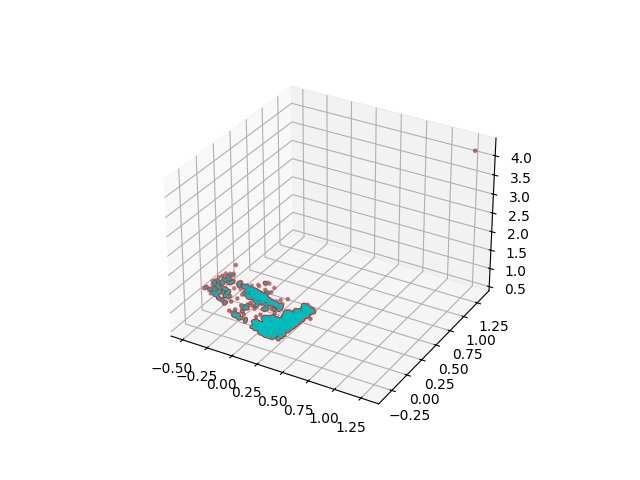

In [23]:
# ------ Your code here ------
nr_pts = XX.shape[1]
x1_s = x[0][0]
x2_s = x[0][1]
P1 = P[0][0]
P2 = P[0][1]

err_list = []
bundle_X = np.zeros((4, nr_pts))
initial_mu = 1000
# XX: 3D points 
# X: Copy of current 3D point that gets updated
# X_new: potential updated X 


# Print the median reprojection error before bundle adjustment
for i in range(nr_pts):
    err, r = compute_reprojection_error(P1,P2,XX[:,i],x1_s[:,i], x2_s[:,i])
    err_list.append(err)

print(f'median of reprojection error is {np.median(err_list)}')
print(f'total reprojection error is {np.sum(err_list)}')

# Perform bundle adjustment by looping through your N points
# For each point, compute the Levenberg-Marquadt update
# Use the update to update the 3D point (the camera matrices are fixed!)

for j in range(nr_pts):

    X = XX[:,j].copy()
    mu = initial_mu
    for i in range(100):

        r, J = linearize_reproj_err(P1,P2,X,x1_s[:,j], x2_s[:,j])
        delta = compute_update(r[0], J, mu=mu)
        
        X_new = X.copy()
        X_new += delta

        err_old, _ = compute_reprojection_error(P1, P2, X, x1_s[:,j], x2_s[:,j])
        err_new, _ = compute_reprojection_error(P1, P2, X_new, x1_s[:,j], x2_s[:,j])
        
        if err_new < err_old:
            X = X_new
            mu = mu/10
        else:
            mu = mu*10
    bundle_X[:,j] = X

err_list = []
for i in range(nr_pts):
    err, r = compute_reprojection_error(P1,P2,bundle_X[:,i],x1_s[:,i], x2_s[:,i])
    err_list.append(err)

# Print the median reprojection error after bundle adjustment
print(f'median of reprojection error is {np.median(err_list)}')
print(f'total reprojection error is {np.sum(err_list)}')

# Plot the refined 3D points in the same plot as the originals
fig14 = plt.figure()
ax14 = fig14.add_subplot(projection="3d")
ax14.scatter(XX[0], XX[1], XX[2], s=5, color='red', label='non refined X')
ax14.scatter(bundle_X[0], bundle_X[1], bundle_X[2], s=1, color='c', label='refined X')
fig14.set_label("P2c")
plt.show()



Compare the total reprojection error (sum of $\sum_{i=1}^m \left\|r_{i}(X_j) \right\|^2 $ over all 3D points) before and after running LM.
Also compare the median reprojection error (median of $\sum_{i=1}^m \left\|r_{i}(X_j) \right\|^2 $ over all 3D points) before and after running LM.

Finally plot the refined 3D points in the same plot as the originals.

Q: **What do you observe?**

A: A mild improvement on the reprojection error from median 11.65 to median 11.19 and a total improvement from 22354 to 21566. 

## **OPTIONAL**: Computer Exercise 4 (10 points)

Perform an empirical noise sensitivity analysis of your LM-solver from the previous exercise.
Add i.i.d. mean-zero Gaussian noise with standard deviation $\sigma_X\in\{0,0.1\mathrm{m}\}$ to the 3D points and $\sigma_x\in\{0,3\mathrm{px}\}$ to the 2D points (from SIFT), yielding (at least) four noise combinations ($\sigma_X$, $\sigma_x$) to try.
See how the total reprojection error and median reprojection error as computed in the previous exercise varies before and after LM with the added noise.
If you want to, you can test other noise types as well.

Q: **Report your findings with plots and numbers in some reasonable manner.**

A: \
TEST 1:\
sigma X = 0.1\
sigma x = 3

Before LM:\
median reprojection error is 268 420\
total reprojection error is 765 004 459

After LM:\
median reprojection error is 33\
total reprojection error is 180 545

---

TEST 2:\
sigma X = 0.05\
sigma x = 3


Before LM:\
median reprojection error is 65 422\
total reprojection error is 175 063 050

After LM:\
median reprojection error is 33\
total reprojection error is 148 533

---

TEST 3:\
sigma X = 0.1\
sigma x = 1

Before LM:\
median reprojection error is 266 667\
total reprojection error is 747 848 549

After LM:\
median reprojection error is 14\
total reprojection error is 119 200

---

TEST 4:\
sigma X = 0.05\
sigma x = 1

Before LM:\
median reprojection error is 67296\
total reprojection error is 182024564

After LM:\
median reprojection error is 14\
total reprojection error is 27236

C:\Users\pontu\AppData\Local\Temp\ipykernel_101556\848718596.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig23 = plt.figure()


median reprojection error is 263351.13247965416
total reprojection error is 726586893.8947505
median reprojection error is 33.12692983214917
total reprojection error is 73758.27068374967
median reprojection error is 64302.716997273674
total reprojection error is 179718735.33056787
median reprojection error is 33.213040504500555
total reprojection error is 72006.57314222476
median reprojection error is 264864.6070597289
total reprojection error is 750564797.6832175
median reprojection error is 14.012096581465634
total reprojection error is 27162.44794874833
median reprojection error is 66630.20405680864
total reprojection error is 178088089.76060715
median reprojection error is 14.225780228079534
total reprojection error is 27317.56296577635


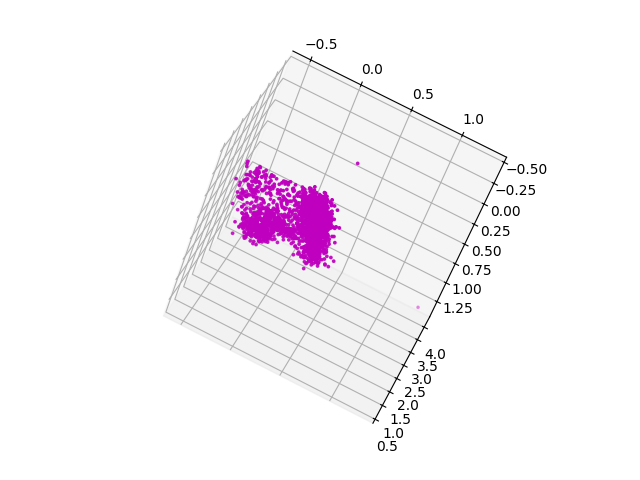

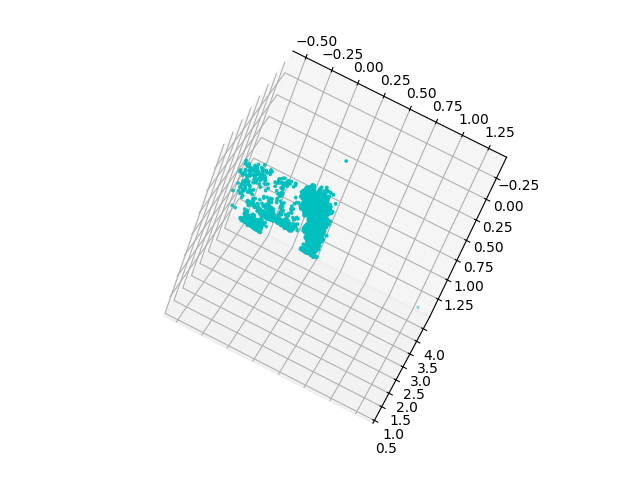

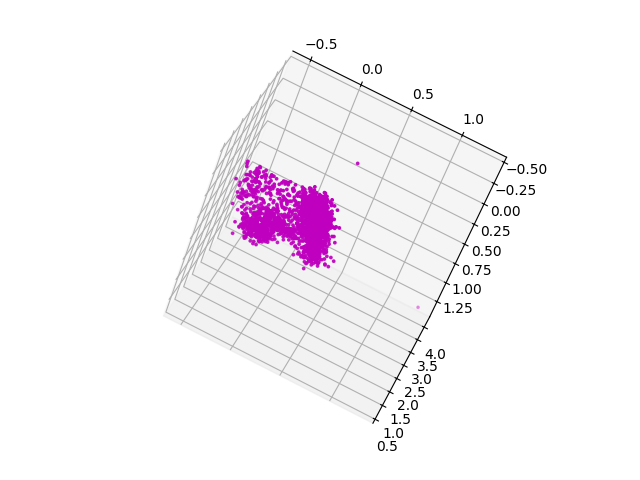

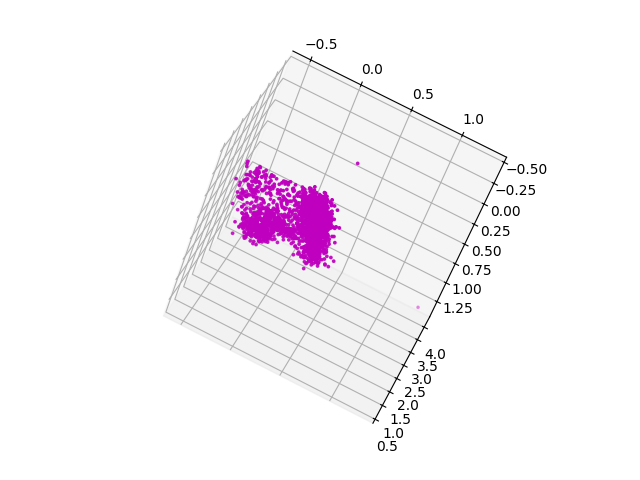

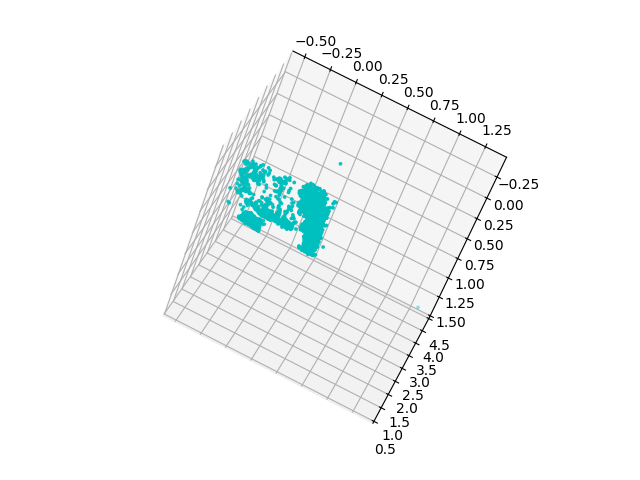

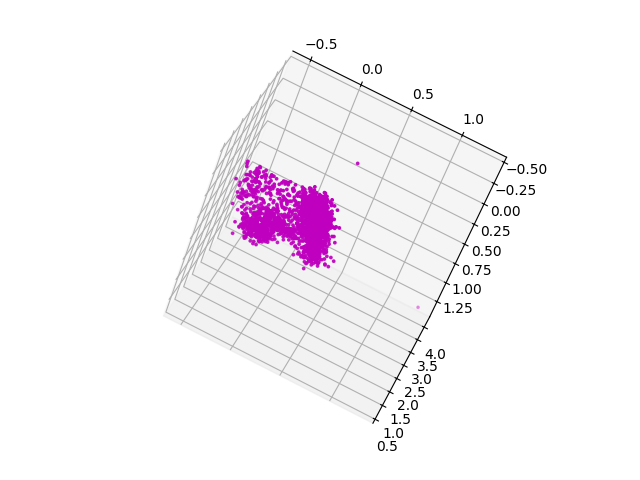

C:\Users\pontu\AppData\Local\Temp\ipykernel_101556\848718596.py:130: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


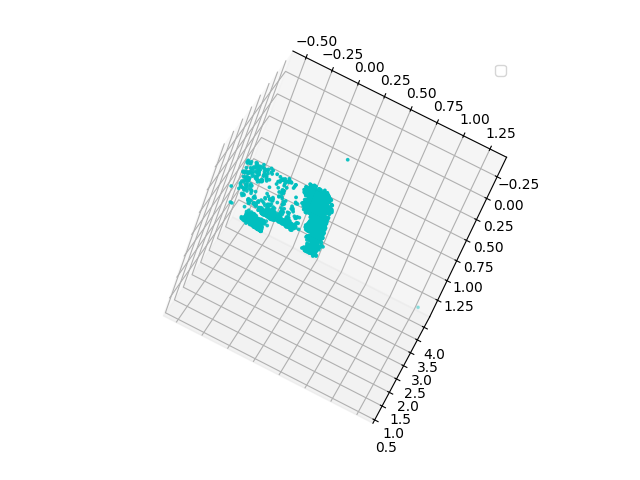

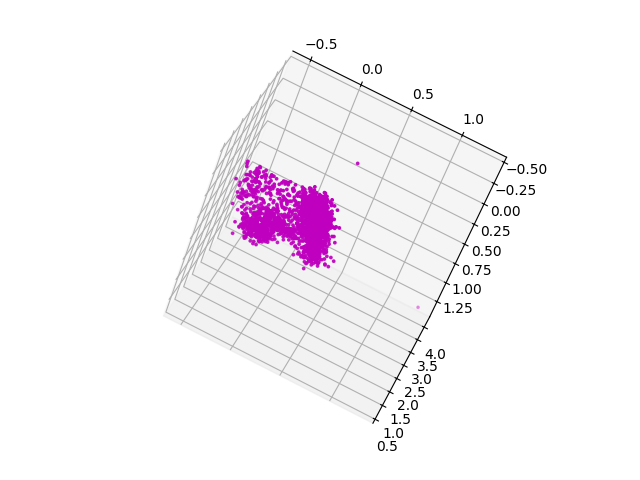

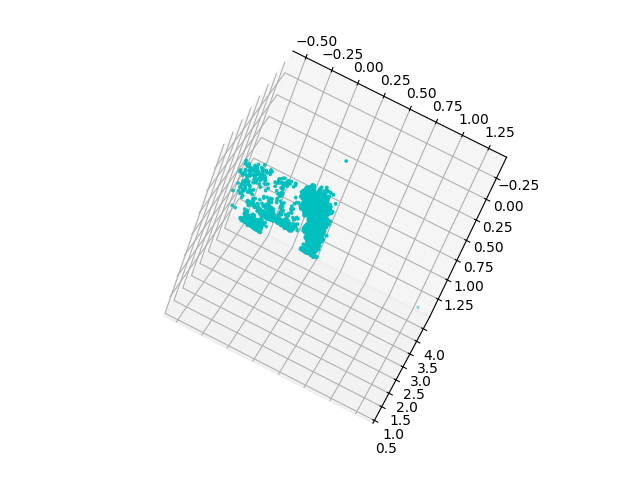

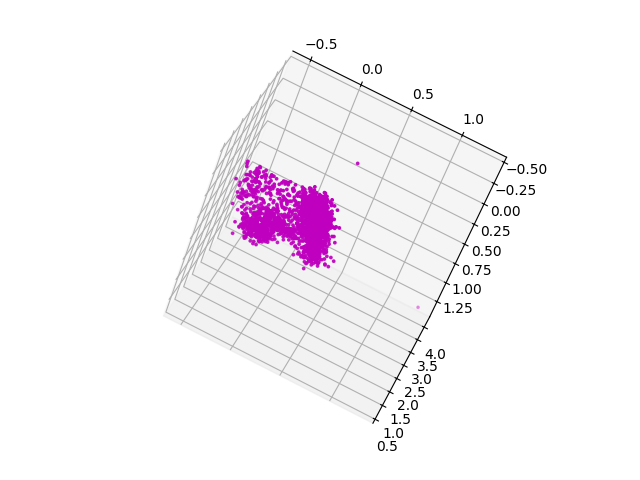

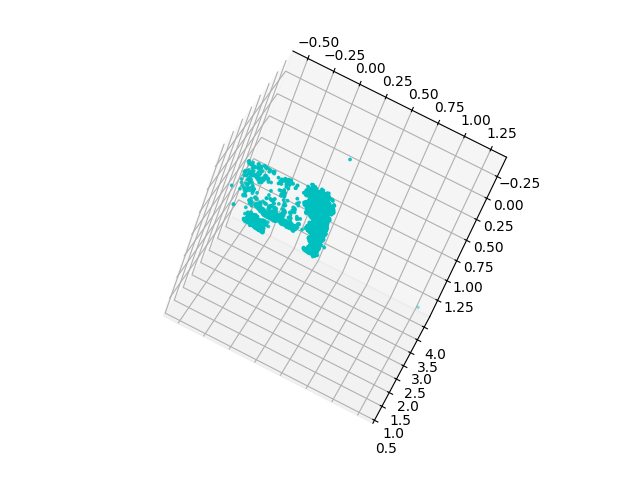

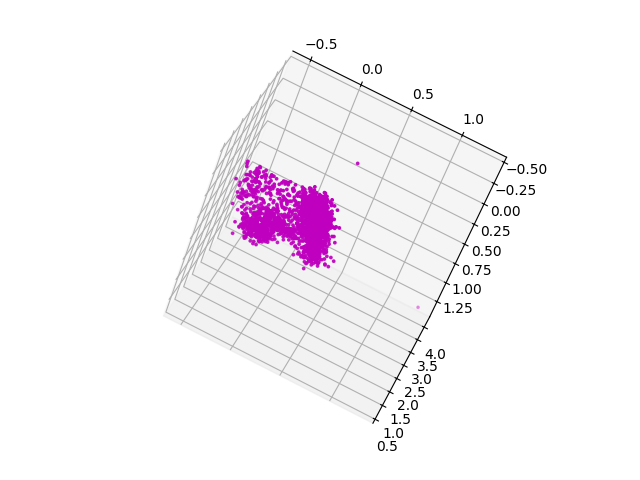

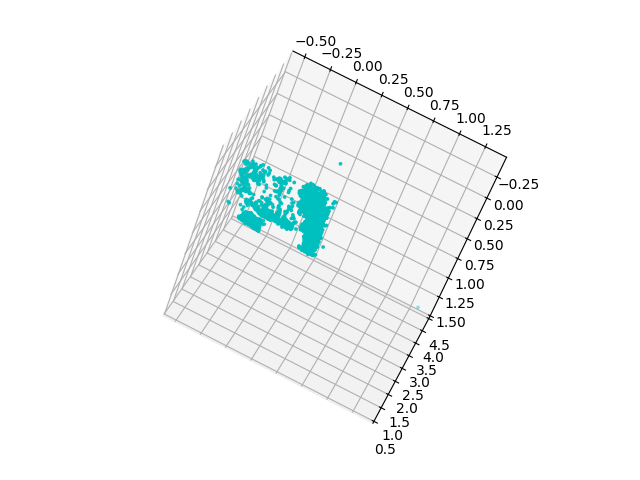

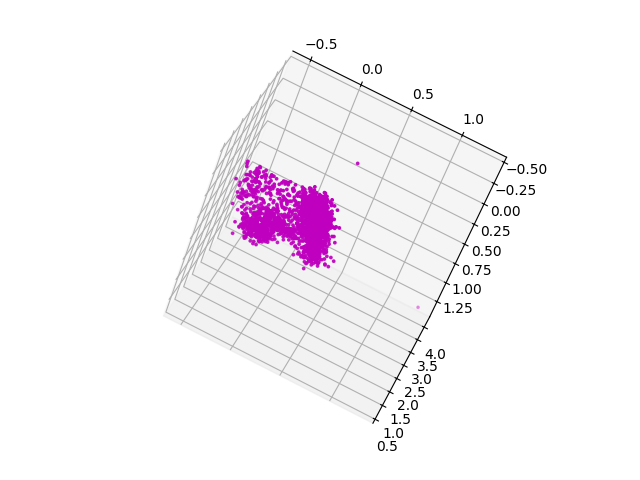

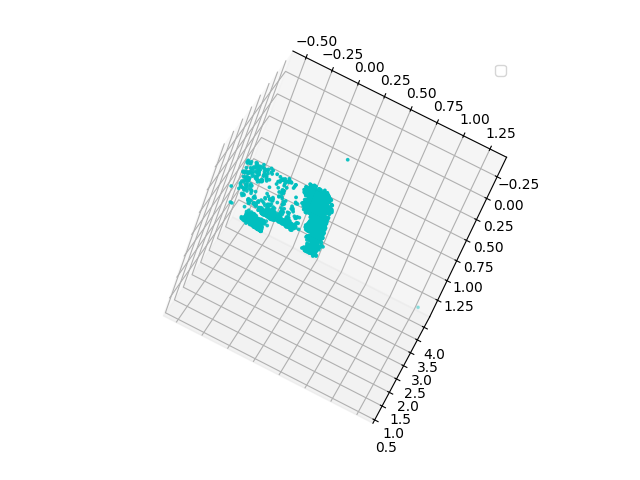

In [24]:
fig201 = plt.figure()
ax201 = fig201.add_subplot(projection='3d')
fig20 = plt.figure()
ax20 = fig20.add_subplot(projection='3d')

fig211 = plt.figure()
ax211 = fig211.add_subplot(projection='3d')
fig21 = plt.figure()
ax21 = fig21.add_subplot(projection='3d')

fig221 = plt.figure()
ax221 = fig221.add_subplot(projection='3d')
fig22 = plt.figure()
ax22 = fig22.add_subplot(projection='3d')

fig231 = plt.figure()
ax231 = fig231.add_subplot(projection='3d')
fig23 = plt.figure()
ax23 = fig23.add_subplot(projection='3d')
# ------ Your code here ------
noisy_X = np.zeros((4, nr_pts))
noisy_x1_s = np.zeros((3, nr_pts))
noisy_x2_s = np.zeros((3, nr_pts))
tot_arr = []
tot_arr_noisy = []

sigma_X = [0.1, 0.05, 0.1, 0.05]   # standard deviation of 0.1 m
sigma_x = [3, 3, 1, 1]   # standard deviation of 3 pixels
for std_X, std_x in zip(sigma_X, sigma_x):
    for i in range(nr_pts):
        noise_X = np.random.normal(0, std_X, size=3)
        noise_x1_s = np.random.normal(0, std_x, size=2)
        noise_x2_s = np.random.normal(0, std_x, size=2)

        noise_X_h = np.hstack([noise_X, 0])
        noise_x1_s_h = np.hstack([noise_x1_s, 0])
        noise_x2_s_h = np.hstack([noise_x2_s, 0])
        
        noisy_X[:,i] = XX[:,i] + noise_X_h
        noisy_x1_s[:,i] = x1_s[:,i] + noise_x1_s_h
        noisy_x2_s[:,i] = x2_s[:,i] + noise_x2_s_h
    tot_arr_noisy.append(noisy_X)
    
    # Printing results before LM 
    err_list = []
    for i in range(nr_pts):
        err, r = compute_reprojection_error(P1,P2,noisy_X[:,i],noisy_x1_s[:,i], noisy_x2_s[:,i])
        err_list.append(err)

    print(f'median reprojection error is {np.median(err_list)}')
    print(f'total reprojection error is {np.sum(err_list)}')

    # LM
    initial_mu = 1000
    bundle_noisy_X = np.zeros((4, nr_pts))
    for j in range(nr_pts):

        X = noisy_X[:,j].copy()
        mu = initial_mu
        err_old, r = compute_reprojection_error(P1,P2,X,noisy_x1_s[:,j], noisy_x2_s[:,j])
        for i in range(20):

            r, J = linearize_reproj_err(P1,P2,X,noisy_x1_s[:,j], noisy_x2_s[:,j])
            delta = compute_update(r[0], J, mu=mu)
        
            X_new = X.copy()
            X_new += delta

            err_new, r = compute_reprojection_error(P1,P2,X_new,noisy_x1_s[:,j], noisy_x2_s[:,j])
            if err_new < err_old:
                X = X_new
                err_old = err_new
                mu = mu/10
            else:
                mu = mu*10
        bundle_noisy_X[:,j] = X
    tot_arr.append((bundle_noisy_X))

    # Printing results after LM
    err_list = []
    for i in range(nr_pts):
        err, r = compute_reprojection_error(P1,P2,bundle_noisy_X[:,i],x1_s[:,i], x2_s[:,i])
        err_list.append(err)

    print(f'median reprojection error is {np.median(err_list)}')
    print(f'total reprojection error is {np.sum(err_list)}')


bundle_noisy_X1, bundle_noisy_X2, bundle_noisy_X3, bundle_noisy_X4 = tot_arr
noisy_X1, noisy_X2, noisy_X3, noisy_X4 = tot_arr_noisy

ax201.scatter(noisy_X1[0], noisy_X1[1], noisy_X1[2], s=3, color='m')
ax201.view_init(elev=-48, azim=-83, roll=-32)
fig201.set_label('noisy X test 1')
fig201.show()

ax20.scatter(bundle_noisy_X1[0], bundle_noisy_X1[1], bundle_noisy_X1[2], s=3, color='c')
ax20.view_init(elev=-48, azim=-83, roll=-32)
fig20.set_label('refined X test 1')
fig20.show()

ax211.scatter(noisy_X2[0], noisy_X2[1], noisy_X2[2], s=3, color='m')
ax211.view_init(elev=-48, azim=-83, roll=-32)
fig211.set_label('noisy X test 2')
fig211.show()

ax21.scatter(bundle_noisy_X2[0], bundle_noisy_X2[1], bundle_noisy_X2[2], s=3, color='c')
ax21.view_init(elev=-48, azim=-83, roll=-32)
fig21.set_label('refined X test 2')
fig211.show()

ax221.scatter(noisy_X3[0], noisy_X3[1], noisy_X3[2], s=3, color='m')
ax221.view_init(elev=-48, azim=-83, roll=-32)
fig221.set_label('noisy X test 3')
fig221.show()

ax22.scatter(bundle_noisy_X3[0], bundle_noisy_X3[1], bundle_noisy_X3[2], s=3, color='c')
ax22.view_init(elev=-48, azim=-83, roll=-32)
fig22.set_label('refined X test 3')
fig22.show()

ax231.scatter(noisy_X4[0], noisy_X4[1], noisy_X4[2], s=3, color='m')
ax231.view_init(elev=-48, azim=-83, roll=-32)
fig231.set_label('noisy X test 4')
fig231.show()

ax23.scatter(bundle_noisy_X4[0], bundle_noisy_X4[1], bundle_noisy_X4[2], s=3, color='c')
ax23.view_init(elev=-48, azim=-83, roll=-32)
fig23.set_label('refined X test 4')
plt.legend()
fig23.show()

